In [ ]:
!pip install --quiet keras-tcn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re
import joblib
import time
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, Add, GlobalAveragePooling1D,
    Dense, LSTM, Bidirectional, AdditiveAttention, LayerNormalization, Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import AdamW
from tcn import TCN
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [ ]:
DRIVE_BASE_PATH = '/content/drive/MyDrive/Colab_ECG_Data/'
ORIG_SIGNALS_PATH = os.path.join(DRIVE_BASE_PATH, 'processed', 'signals')
GAN_OUTPUT_PATH = os.path.join(DRIVE_BASE_PATH, 'GAN_Output')
DL_GAN_MODELS_PATH = os.path.join(DRIVE_BASE_PATH, 'models', 'dl_gan_balanced')
os.makedirs(DL_GAN_MODELS_PATH, exist_ok=True)

print("Orijinal ham veriler (train/val/test) yükleniyor...")

X_train_raw_orig = np.load(os.path.join(ORIG_SIGNALS_PATH, 'X_train_sig.npy'))
y_train_orig = np.load(os.path.join(ORIG_SIGNALS_PATH, 'y_train.npy'))
X_val_raw = np.load(os.path.join(ORIG_SIGNALS_PATH, 'X_val_sig.npy'))
y_val = np.load(os.path.join(ORIG_SIGNALS_PATH, 'y_val.npy'))
X_test_raw = np.load(os.path.join(ORIG_SIGNALS_PATH, 'X_test_sig.npy'))
y_test = np.load(os.path.join(ORIG_SIGNALS_PATH, 'y_test.npy'))

print("GAN ile üretilmiş sentetik veriler (B planı) yükleniyor...")
X_train_synthetic = np.load(os.path.join(GAN_OUTPUT_PATH, 'synthetic_signals_all_minority_B.npy'))
y_train_synthetic = np.load(os.path.join(GAN_OUTPUT_PATH, 'synthetic_labels_all_minority_B.npy'))

print("\n--- Veri Birleştirme ve Standardizasyon ---")


X_train_balanced = np.concatenate((X_train_raw_orig, X_train_synthetic), axis=0)
y_train_balanced = np.concatenate((y_train_orig, y_train_synthetic), axis=0)

print(f"Yeni Dengelenmiş Eğitim Seti Boyutu: {X_train_balanced.shape}")

N_LEADS = X_train_raw_orig.shape[2]
scaler = StandardScaler()
X_train_orig_reshaped = X_train_raw_orig.reshape(-1, N_LEADS)
scaler.fit(X_train_orig_reshaped)


def scale_data(data, scaler_obj):
    data_reshaped = data.reshape(-1, N_LEADS)
    data_scaled = scaler_obj.transform(data_reshaped)
    return data_scaled.reshape(data.shape)

X_train_scaled = scale_data(X_train_balanced, scaler)
X_val_scaled = scale_data(X_val_raw, scaler)
X_test_scaled = scale_data(X_test_raw, scaler)
print("Tüm veriler (eğitim, doğrulama, test) standardize edildi.")


scaler_path = os.path.join(DL_GAN_MODELS_PATH, 'dl_scaler_gan.pkl')
joblib.dump(scaler, scaler_path)
print(f"Yeni DL Scaler (GAN) '{scaler_path}' adresine kaydedildi.")


N_CLASSES = 5
y_train_cat = to_categorical(y_train_balanced, num_classes=N_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=N_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=N_CLASSES)
print("Tüm etiketler 'categorical' formata dönüştürüldü.")

print(f"\nModeller '{DL_GAN_MODELS_PATH}' yoluna kaydedilecek.")

Orijinal ham veriler (train/val/test) yükleniyor...
GAN ile üretilmiş sentetik veriler (B planı) yükleniyor...

--- Veri Birleştirme ve Standardizasyon ---
Yeni Dengelenmiş Eğitim Seti Boyutu: (173949, 250, 12)
Tüm veriler (eğitim, doğrulama, test) standardize edildi.
Yeni DL Scaler (GAN) '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/dl_scaler_gan.pkl' adresine kaydedildi.
Tüm etiketler 'categorical' formata dönüştürüldü.

Modeller '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced' yoluna kaydedilecek.


In [ ]:
def build_lstm_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    x = SpatialDropout1D(0.1)(inputs)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = BatchNormalization()(x)

    attn_output = AdditiveAttention(name='attention_layer')([x, x])

    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
def tcn_block(inputs, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(0.1)(x)

    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(0.1)(x)

    # Residual (artık) bağlantı
    if inputs.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(inputs)
    else:
        shortcut = inputs

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_tcn_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    x = tcn_block(inputs, 64, 3, dilation_rate=1)
    x = tcn_block(x, 64, 3, dilation_rate=2)
    x = tcn_block(x, 128, 3, dilation_rate=4)
    x = tcn_block(x, 128, 3, dilation_rate=8)

    attn_output = AdditiveAttention(name='attention_layer')([x, x])

    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
def resnet_identity_block(inputs, filters, kernel_size):
    """Boyut değiştirmeyen ResNet bloğu"""
    shortcut = inputs

    x = Conv1D(filters, kernel_size, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def resnet_conv_block(inputs, filters, kernel_size, strides):
    """Boyut değiştiren (azaltan) ResNet bloğu"""
    shortcut = inputs

    x = Conv1D(filters, kernel_size, strides=strides, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Shortcut'u da aynı boyuta getir
    shortcut = Conv1D(filters, 1, strides=strides, padding='same')(shortcut)
    shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_resnet34_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    # Giriş Katmanı
    x = Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # ResNet-34 Blokları [3, 4, 6, 3]
    # Conv2_x (3 blok)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_identity_block(x, 64, 3)

    # Conv3_x (4 blok)
    x = resnet_conv_block(x, 128, 3, strides=2)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_identity_block(x, 128, 3)

    # Conv4_x (6 blok)
    x = resnet_conv_block(x, 256, 3, strides=2)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)

    # Conv5_x (3 blok)
    x = resnet_conv_block(x, 512, 3, strides=2)
    x = resnet_identity_block(x, 512, 3)
    x = resnet_identity_block(x, 512, 3)

    # Attention Mekanizması
    # Modelin sonundaki diziyi (shape=(None, 32, 512)) alır
    attn_output = AdditiveAttention(name='attention_layer')([x, x])

    # Çıkış
    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
models = {
    "LSTM_with_Attention_GAN": build_lstm_with_attention(),
    "TCN_with_Attention_GAN": build_tcn_with_attention(),
    "ResNet34_with_Attention_GAN": build_resnet34_with_attention()
}

results = {}

BATCH_SIZE = 32
EPOCHS = 50

for name, model in models.items():
    print(f"\n\n--- Model Eğitimi Başlıyor: {name} ---")

    current_batch_size = BATCH_SIZE
    print(f"(Batch Size: {current_batch_size})")

    checkpoint_path_format = os.path.join(DL_GAN_MODELS_PATH, f'checkpoint_{name.lower()}_epoch_{{epoch:02d}}.weights.h5')

    initial_epoch_num = 0
    latest_checkpoint_file = None
    search_pattern = os.path.join(DL_GAN_MODELS_PATH, f'checkpoint_{name.lower()}_epoch_*.weights.h5')
    checkpoint_files = glob.glob(search_pattern)
    if checkpoint_files:
        latest_epoch = -1
        for f in checkpoint_files:
            match = re.search(r'_epoch_(\d+)\.weights\.h5$', f)
            if match:
                epoch_num = int(match.group(1))
                if epoch_num > latest_epoch:
                    latest_epoch = epoch_num
                    latest_checkpoint_file = f
        if latest_checkpoint_file:
            try:
                model.load_weights(latest_checkpoint_file)
                initial_epoch_num = latest_epoch
                print(f"'{latest_checkpoint_file}' (Epoch {latest_epoch}) yüklendi. Eğitime Epoch {initial_epoch_num + 1}'den devam edilecek...")
            except Exception as e:
                print(f"Hata: Checkpoint dosyası '{latest_checkpoint_file}' yüklenemedi. Baştan başlanacak. (Hata: {e})")
        else:
             print("Checkpoint dosyaları bulundu ancak epoch numarası okunamadı. Baştan başlanacak.")
    else:
        print("Daha önce kaydedilmiş checkpoint bulunamadı. Eğitime baştan başlanacak.")


    model_checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path_format,
        save_weights_only=True,
        save_best_only=False,
        save_freq='epoch'
        )

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001),
        model_checkpoint_callback
    ]

    if initial_epoch_num < EPOCHS:
        print("Eğitim başlıyor...")
        history = model.fit(

            X_train_scaled, y_train_cat,

            validation_data=(X_val_scaled, y_val_cat),
            epochs=EPOCHS,
            initial_epoch=initial_epoch_num,
            batch_size=current_batch_size,
            callbacks=callbacks,
            verbose=1
        )
    else:
        print(f"{name} için {EPOCHS} epoch zaten tamamlanmış. Eğitim atlanıyor.")
        if latest_checkpoint_file:
             try:
                 model.load_weights(latest_checkpoint_file)
                 print(f"Eğitim atlandı, son checkpoint '{latest_checkpoint_file}' yüklendi.")
             except Exception as e:
                 print(f"Eğitim atlandı ancak son checkpoint yüklenemedi: {e}")


    print(f"\n--- {name} Model Değerlendirmesi (50. Epoch Sonu) (Test Seti) ---")


    preds_proba = model.predict(X_test_scaled)
    preds = np.argmax(preds_proba, axis=1)
    y_true = y_test

    acc = accuracy_score(y_true, preds)
    bal_acc = balanced_accuracy_score(y_true, preds)
    prec_macro = precision_score(y_true, preds, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, preds, average='macro', zero_division=0)
    roc_auc_macro = roc_auc_score(y_test_cat, preds_proba, multi_class='ovr', average='macro')

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Balanced Accuracy: {bal_acc:.4f}")

    report = classification_report(y_true, preds)
    print("\nSınıflandırma Raporu:")
    print(report)

    results[name] = {
        'accuracy': acc, 'balanced_accuracy': bal_acc, 'precision_macro': prec_macro,
        'recall_macro': rec_macro, 'f1_score_macro': f1_macro, 'roc_auc_ovr_macro': roc_auc_macro,
        'report': report
    }

    model_path = os.path.join(DL_GAN_MODELS_PATH, f'{name.lower()}_epoch50.h5')
    model.save(model_path)
    print(f"Baseline {name} modeli (50. epoch) '{model_path}' klasörüne kaydedildi.")

print("\n\n--- TÜM DERİN ÖĞRENME (GAN) MODELLERİNİN EĞİTİMİ (50 EPOCH) TAMAMLANDI ---")

# Final özeti
print("\n--- Model Özet Sonuçları (50. Epoch Sonu) ---")
for name, metrics in results.items():
    print(f"\nModel: {name}")
    print(f"  Test Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Test Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Test F1 Score (Macro): {metrics['f1_score_macro']:.4f}")



--- Model Eğitimi Başlıyor: LSTM_with_Attention_GAN ---
(Batch Size: 32)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


'/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/checkpoint_lstm_with_attention_gan_epoch_50.weights.h5' (Epoch 50) yüklendi. Eğitime Epoch 51'den devam edilecek...
LSTM_with_Attention_GAN için 50 epoch zaten tamamlanmış. Eğitim atlanıyor.
Eğitim atlandı, son checkpoint '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/checkpoint_lstm_with_attention_gan_epoch_50.weights.h5' yüklendi.

--- LSTM_with_Attention_GAN Model Değerlendirmesi (50. Epoch Sonu) (Test Seti) ---
535/535 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


Test Accuracy: 0.9639
Test Balanced Accuracy: 0.9340

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2152
           1       0.98      0.81      0.89      1053
           2       0.97      0.98      0.97      4375
           3       0.97      0.98      0.98      7611
           4       0.91      0.93      0.92      1920

    accuracy                           0.96     17111
   macro avg       0.96      0.93      0.95     17111
weighted avg       0.96      0.96      0.96     17111

Baseline LSTM_with_Attention_GAN modeli (50. epoch) '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/lstm_with_attention_gan_epoch50.h5' klasörüne kaydedildi.


--- Model Eğitimi Başlıyor: TCN_with_Attention_GAN ---
(Batch Size: 32)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 84 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


'/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/checkpoint_tcn_with_attention_gan_epoch_50.weights.h5' (Epoch 50) yüklendi. Eğitime Epoch 51'den devam edilecek...
TCN_with_Attention_GAN için 50 epoch zaten tamamlanmış. Eğitim atlanıyor.
Eğitim atlandı, son checkpoint '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/checkpoint_tcn_with_attention_gan_epoch_50.weights.h5' yüklendi.

--- TCN_with_Attention_GAN Model Değerlendirmesi (50. Epoch Sonu) (Test Seti) ---
535/535 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step


Test Accuracy: 0.9625
Test Balanced Accuracy: 0.9505

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2152
           1       0.98      0.91      0.95      1053
           2       0.99      0.94      0.96      4375
           3       0.97      0.99      0.98      7611
           4       0.87      0.96      0.92      1920

    accuracy                           0.96     17111
   macro avg       0.96      0.95      0.95     17111
weighted avg       0.96      0.96      0.96     17111

Baseline TCN_with_Attention_GAN modeli (50. epoch) '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/tcn_with_attention_gan_epoch50.h5' klasörüne kaydedildi.


--- Model Eğitimi Başlıyor: ResNet34_with_Attention_GAN ---
(Batch Size: 32)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 296 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


'/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/checkpoint_resnet34_with_attention_gan_epoch_50.weights.h5' (Epoch 50) yüklendi. Eğitime Epoch 51'den devam edilecek...
ResNet34_with_Attention_GAN için 50 epoch zaten tamamlanmış. Eğitim atlanıyor.
Eğitim atlandı, son checkpoint '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/checkpoint_resnet34_with_attention_gan_epoch_50.weights.h5' yüklendi.

--- ResNet34_with_Attention_GAN Model Değerlendirmesi (50. Epoch Sonu) (Test Seti) ---
535/535 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step


Test Accuracy: 0.9703
Test Balanced Accuracy: 0.9565

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2152
           1       0.98      0.93      0.95      1053
           2       0.97      0.97      0.97      4375
           3       0.98      0.99      0.98      7611
           4       0.94      0.94      0.94      1920

    accuracy                           0.97     17111
   macro avg       0.97      0.96      0.96     17111
weighted avg       0.97      0.97      0.97     17111

Baseline ResNet34_with_Attention_GAN modeli (50. epoch) '/content/drive/MyDrive/Colab_ECG_Data/models/dl_gan_balanced/resnet34_with_attention_gan_epoch50.h5' klasörüne kaydedildi.


--- TÜM DERİN ÖĞRENME (GAN) MODELLERİNİN EĞİTİMİ (50 EPOCH) TAMAMLANDI ---

--- Model Özet Sonuçları (50. Epoch Sonu) ---

Model: LSTM_with_Attention_GAN
  Test Accuracy: 0.9639
  Test Balanced Accuracy: 0.9340
  Test F1 Score (Macro): 0.9454

Model: TC


--- DERİN ÖĞRENME MODELLERİ KARŞILAŞTIRMALI SONUÇ TABLOSU (TEST SETİ) ---
                             accuracy  balanced_accuracy  precision_macro  \
LSTM_with_Attention_GAN        0.9639             0.9340           0.9604   
TCN_with_Attention_GAN         0.9625             0.9505           0.9572   
ResNet34_with_Attention_GAN    0.9703             0.9565           0.9672   

                             recall_macro  f1_score_macro  roc_auc_ovr_macro  
LSTM_with_Attention_GAN            0.9340          0.9454             0.9982  
TCN_with_Attention_GAN             0.9505          0.9530             0.9981  
ResNet34_with_Attention_GAN        0.9565          0.9617             0.9984  


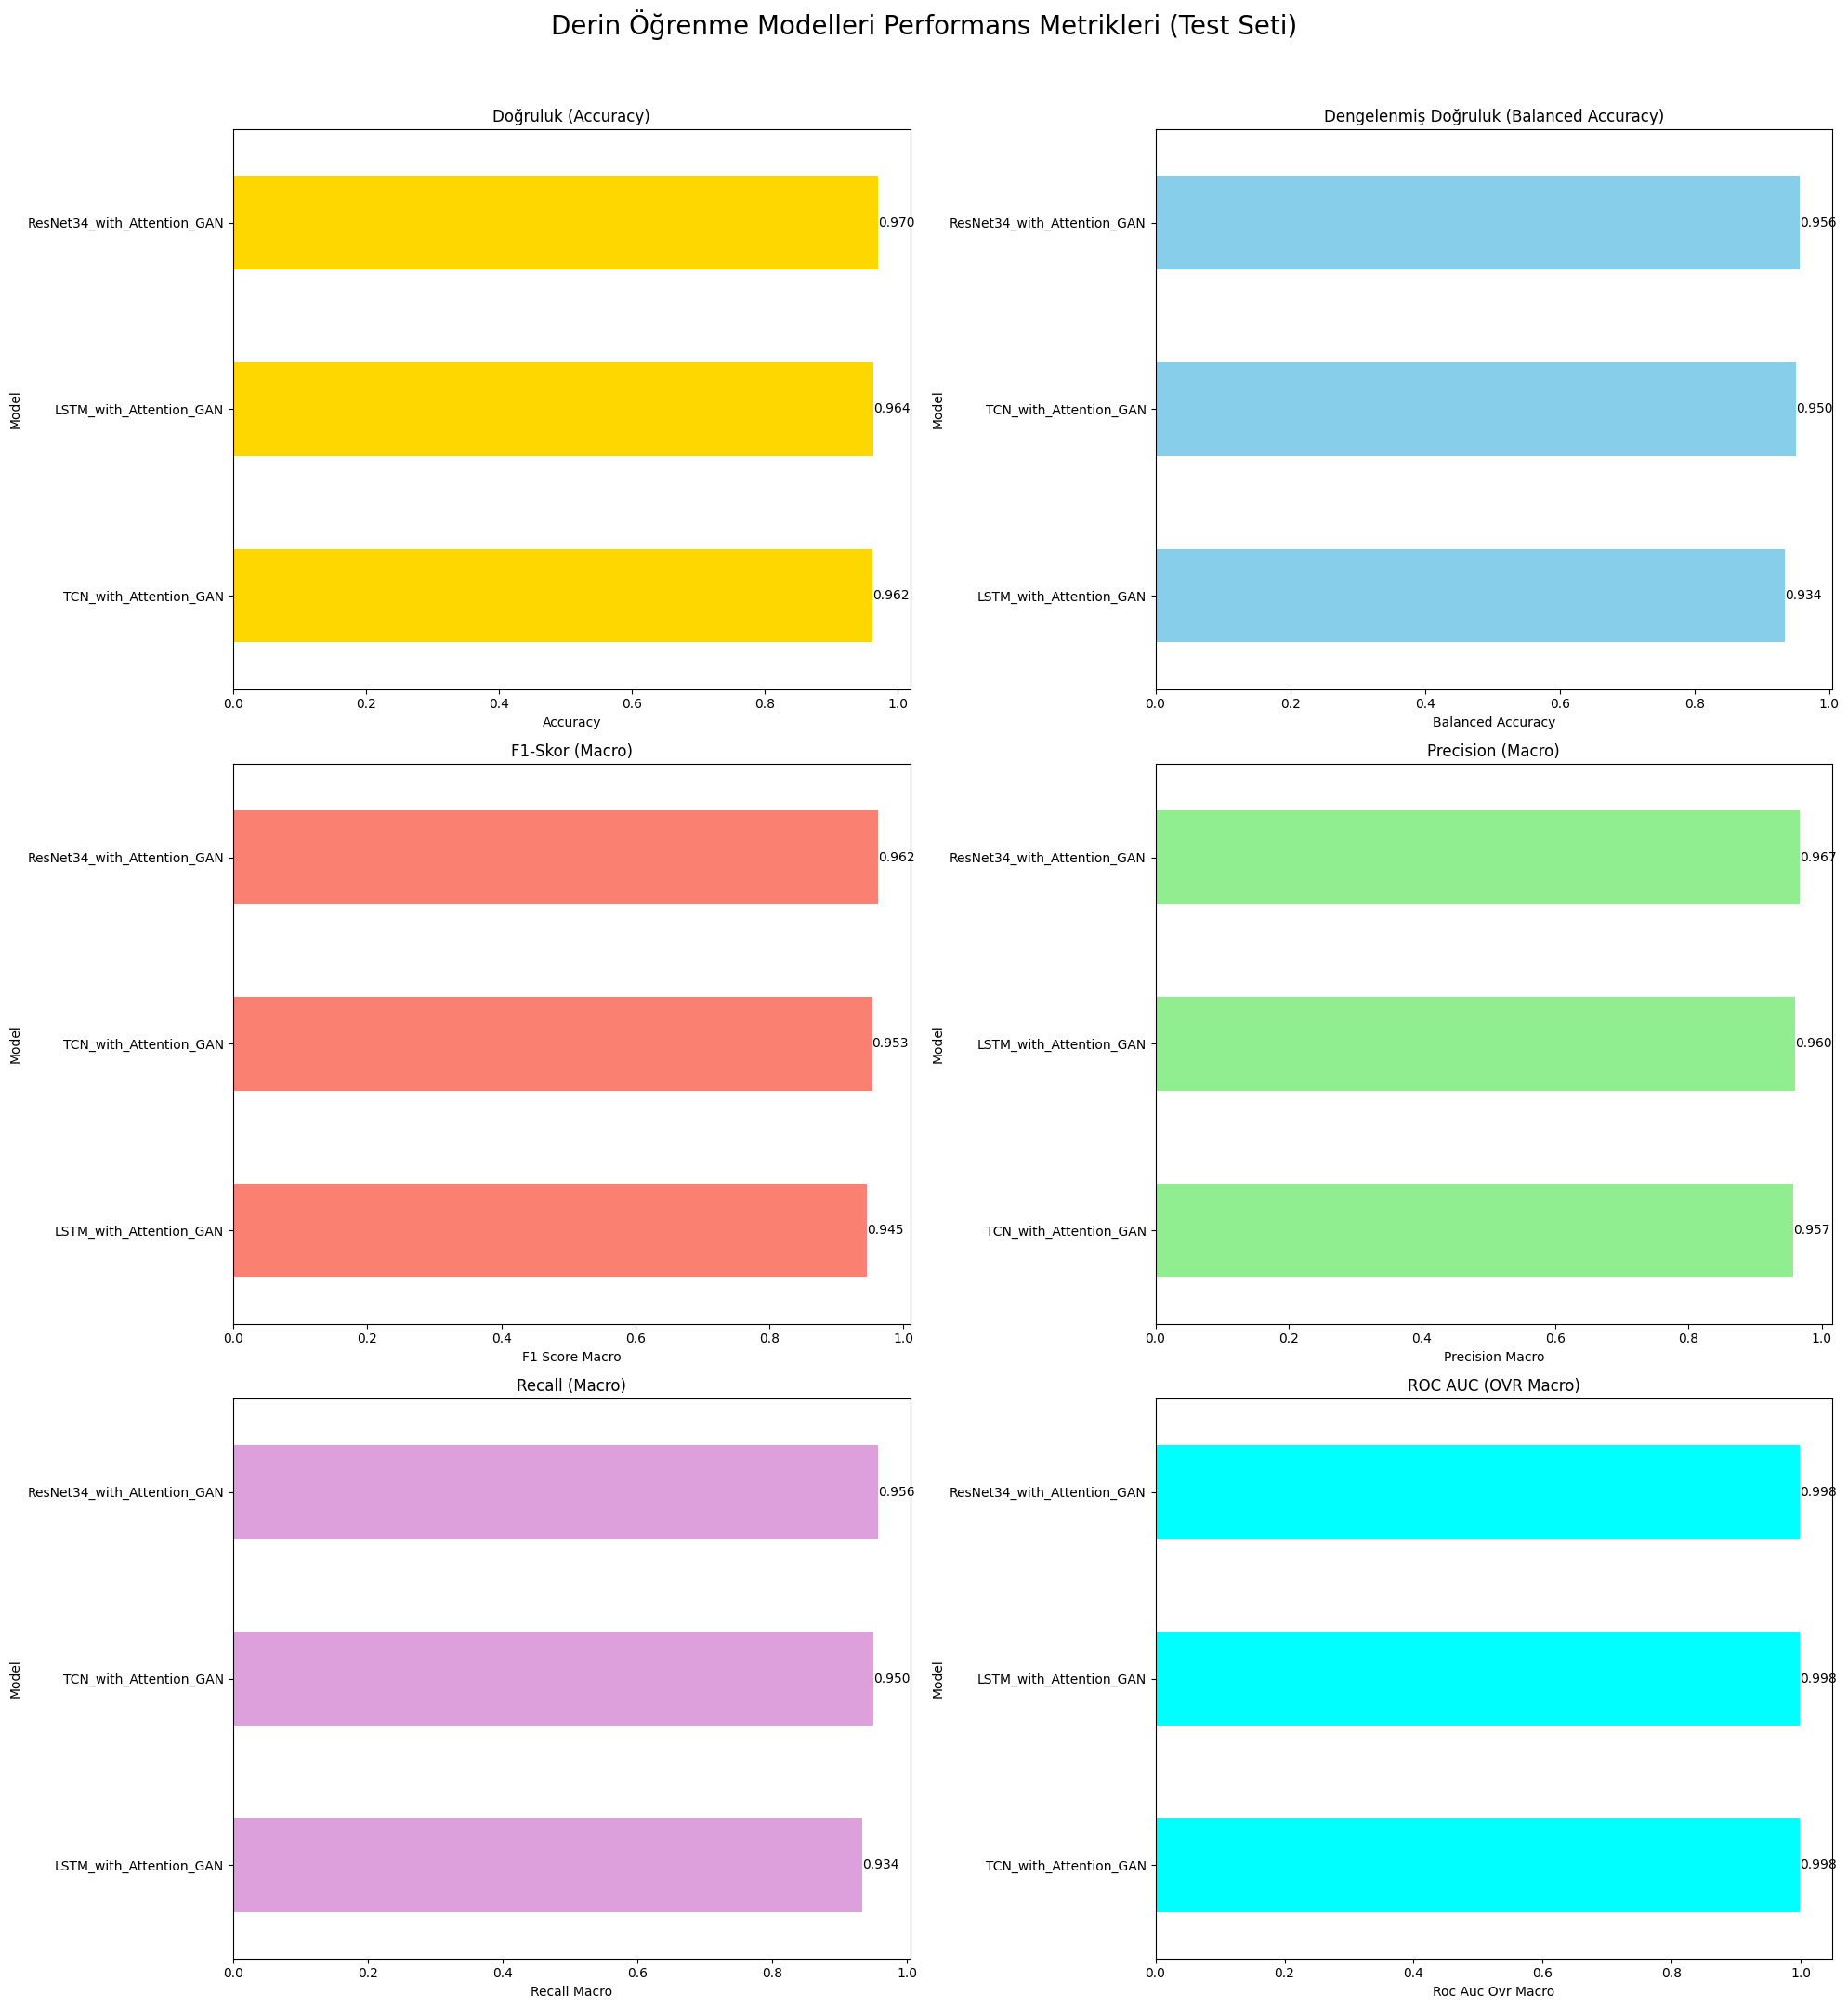

In [ ]:
if 'results' in locals() and results:
    results_for_df = {}
    for model_name, metrics_dict in results.items():
        for metric_name, value in metrics_dict.items():
            if metric_name != 'report':
                if metric_name not in results_for_df:
                    results_for_df[metric_name] = {}
                results_for_df[metric_name][model_name] = value

    results_df_dl = pd.DataFrame(results_for_df)

    print("\n--- DERİN ÖĞRENME MODELLERİ KARŞILAŞTIRMALI SONUÇ TABLOSU (TEST SETİ) ---")
    print(results_df_dl.round(4))


    fig, axes = plt.subplots(3, 2, figsize=(20, 22))
    fig.suptitle('Derin Öğrenme Modelleri Performans Metrikleri (Test Seti)', fontsize=20)
    axes = axes.flatten()

    metrics_to_plot = {
        'accuracy': 'Doğruluk (Accuracy)',
        'balanced_accuracy': 'Dengelenmiş Doğruluk (Balanced Accuracy)',
        'f1_score_macro': 'F1-Skor (Macro)',
        'precision_macro': 'Precision (Macro)',
        'recall_macro': 'Recall (Macro)',
        'roc_auc_ovr_macro': 'ROC AUC (OVR Macro)'
    }

    colors = ['gold', 'skyblue', 'salmon', 'lightgreen', 'plum', 'cyan']

    plot_counter = 0
    for i, (metric, title) in enumerate(metrics_to_plot.items()):
        if metric in results_df_dl.columns:
            ax = axes[plot_counter]
            results_df_dl[metric].sort_values().plot(
                kind='barh', ax=ax, color=colors[i], title=title
            )
            ax.set_xlabel(metric.replace('_', ' ').title())
            ax.set_ylabel("Model")

            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f')
            plot_counter += 1

    if plot_counter < len(axes):
        for i in range(plot_counter, len(axes)):
            axes[i].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

else:
    print("\n'results' sözlüğü bulunamadı veya boş. Lütfen önce Hücre 5'i çalıştırıp modelleri eğitin.")

--- 3 DL MODELİ İÇİN SAYISAL KARMAŞIKLIK MATRİSLERİ ---

--- LSTM_with_Attention_GAN ---


535/535 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step


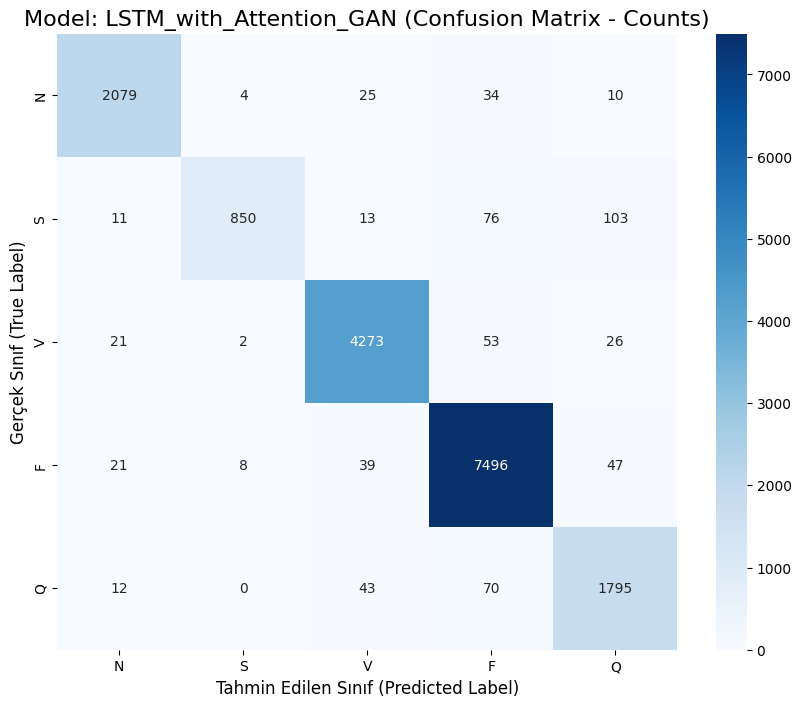


--- TCN_with_Attention_GAN ---


535/535 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


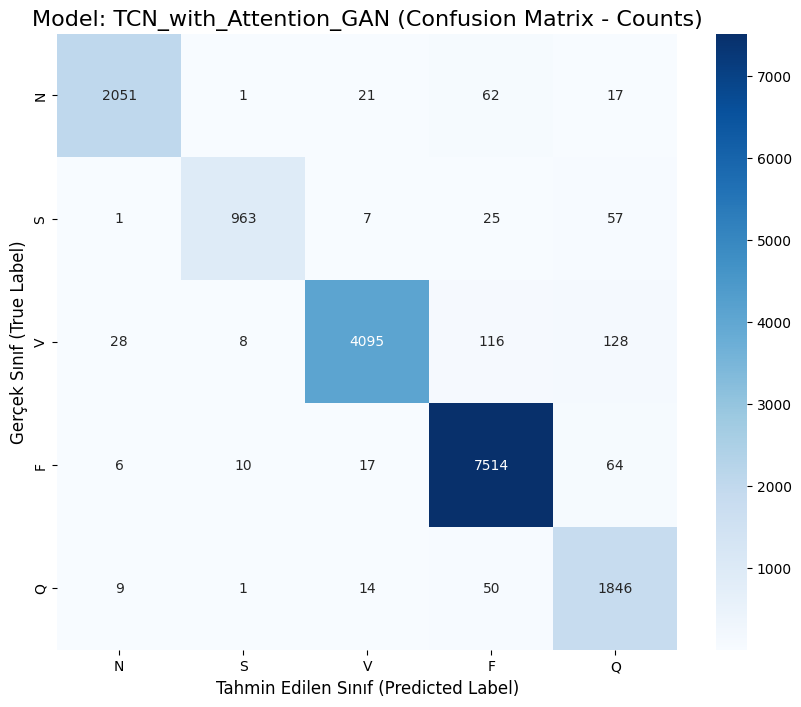


--- ResNet34_with_Attention_GAN ---


535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


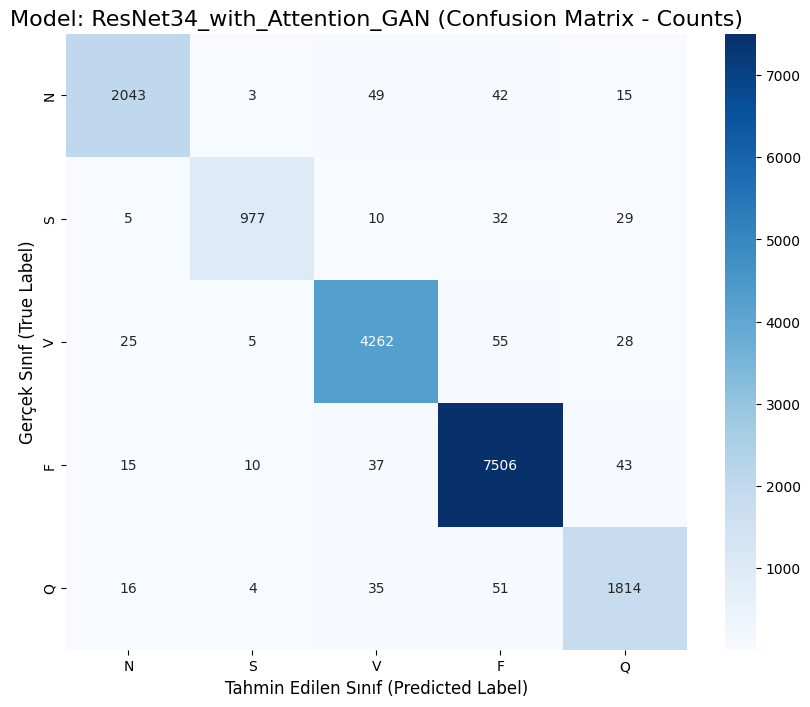


--- DL Matrisleri Tamamlandı. ---


In [ ]:
print("--- 3 DL MODELİ İÇİN SAYISAL KARMAŞIKLIK MATRİSLERİ ---")

CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']

def plot_cm_counts(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"Model: {model_name} (Confusion Matrix - Counts)", fontsize=16)
    plt.ylabel('Gerçek Sınıf (True Label)', fontsize=12)
    plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)', fontsize=12)
    plt.show()

model_names_dl = [
    "LSTM_with_Attention_GAN",
    "TCN_with_Attention_GAN",
    "ResNet34_with_Attention_GAN"
]


for name in model_names_dl:
    print(f"\n--- {name} ---")
    try:
        model_filename = f'{name.lower()}_epoch50.h5'
        model_path = os.path.join(DL_GAN_MODELS_PATH, model_filename)

        model = load_model(model_path)
        preds_proba = model.predict(X_test_scaled)
        preds = np.argmax(preds_proba, axis=1)

        plot_cm_counts(y_test, preds, name)

    except Exception as e:
        print(f"HATA ({name}): {e}")

print("\n--- DL Matrisleri Tamamlandı. ---")